In [7]:
import sys
sys.path.append('../')
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores


from scipy.ndimage import gaussian_filter

import qutip as qt
import utils_2Q_gate_zp as ut
import numpy as np
import matplotlib.pyplot as plt
workers=150


def plot_evolution(hspace, tlist, props, logical = [0,2], intermediate=7, divide=10, s = 0.1, suptitle=""):

    # Get population of logical states, intermediate states, and other states < or >= divide
    pops = np.zeros((2, 5, len(props)))
    logical_idx = [hspace.index(i) for i in logical]
    int_idx = hspace.index(intermediate)
    others_low = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and hspace[i] < divide]
    others_high = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and hspace[i] >= divide]
    f, ax = plt.subplots(ncols=2, figsize=(8,3))
    for i in range(len(logical_idx)):
        pops[i,0] = np.abs([p[logical_idx[0], logical_idx[i]] for p in props])**2
        pops[i,1] = np.abs([p[logical_idx[1], logical_idx[i]] for p in props])**2
        pops[i,2] = np.abs([p[int_idx, logical_idx[i]] for p in props])**2
        for o in others_low:
            pops[i,3] += np.abs([p[o, logical_idx[i]] for p in props])**2
        for o in others_high:
            pops[i,4] += np.abs([p[o, logical_idx[i], ] for p in props])**2

        ax[i].plot(tlist, gaussian_filter(pops[i, 0], s), label=logical[0])
        ax[i].plot(tlist, gaussian_filter(pops[i, 1], s),label=logical[1])
        ax[i].plot(tlist, gaussian_filter(pops[i, 2], s), label=intermediate)
        ax[i].plot(tlist, gaussian_filter(pops[i, 3], s), label=f"others < {divide}")
        ax[i].plot(tlist, gaussian_filter(pops[i, 4], s), label=f"others >= {divide}")
        ax[i].legend()
        ax[i].set_title("Start in " + str(hspace[i]))
        ax[i].set_xlabel("time (ns)")
        ax[i].set_ylabel("population")
    if suptitle != "":
        plt.suptitle(suptitle)
    return pops

The point of this notebook is to provide an example of a control pulse on a single qubit X gate which performs well with few states, but performs poorly when more are included. To do this we consider driving the $n_\phi$ operator for a single qubit X gate in zero pi.

Using the reduced model notebook, we previously showed that most of the leakage is coming through the states: [10, 11, 16, 19, 23, 25, 31, 33]  

First define the system Hamiltonian

In [8]:
trunc1 = 300
[H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi=False, drive_theta=True, truncation=trunc1, thresh=0)
H0 = (H0 - H0[0,0]).full()
H0 = qt.Qobj(H0)

Drive params

In [9]:
# tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.25608649, 0.07794329, 0.11955189, -0.24261886, -0.08178298, 0.        ]
# tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [-0.6520177423300577, 0.13025113024382667, 0.03511481797536371, 0.0027635017015126316, 0.003117052557145257, 0.0]
# tg = 100+tg_wiggle

tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [2.3269535727932906, 0.07856158512805404, 0.02151270460980805, 0.002575344788868055, 0.0034223774721074476, 0.0]
tg_base = 50
tg = tg_base + tg_mod

# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [2.0442468498343036, 0.09932697490825865, 0.02724595848614569, 0.0027264201770088726, 0.004082079467309914, 0.0]
# tg_base = 40
# tg = tg_base + tg_mod


# tg,fidelity_truc44,fidelity_truc157,amp_A,amp_B,detune_A,detune_B = 30.0,-2.876481,-3.07440094,0.144862,0.038029,0.000865,0.003487

hspace_reduced = [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 23, 25, 30, 32, 38, 45, 46]

pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': 0,
             'alpha_B': 0 }
pulse_args

{'drive_amp_A': 0.07856158512805404,
 'drive_freq_A': 43.88984133541911,
 'drive_amp_B': 0.02151270460980805,
 'drive_freq_B': 22.51640256452278,
 'gate_time': 52.32695357279329,
 'alpha_A': 0,
 'alpha_B': 0}

In [10]:
# Save to npz for julia
np.savez("H_theta.npz", H0=H0, drive=drive_term, w_trans_1=w_trans_1, w_trans_2=w_trans_2, hspace_reduced=hspace_reduced, hspace_full=np.arange(trunc1), **pulse_args)

# Show fidelities and plot populations

In [15]:
workers = 1
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]
1 - 10**ut.xgate_fidelity_fast(argz)

0.9999997777148724

In [16]:
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]
1 - 10**ut.xgate_fidelity(argz)

0.9999997800833986

In [45]:
tlist, props = ut.xgate_propagator(argz, num=1000)

(1e-05, 1)

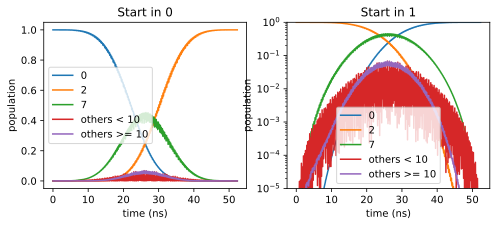

In [46]:
plot_evolution(hspace_reduced, tlist, props, s=0);
plt.gca().set_yscale("log")
plt.gca().set_ylim(1e-05, 1)

In [18]:
hspace_full = list(np.arange(300))
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]

In [19]:
workers = 1
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]
1 - 10**ut.xgate_fidelity_fast(argz)

0.9984254529119584

In [20]:
workers = 1
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]
ut.xgate_fidelity(argz)

-2.801977635774751

In [21]:
1- 10**-2.801977635774751

0.9984223074882778

In [49]:
tlist, props = ut.xgate_propagator(argz, num=300)

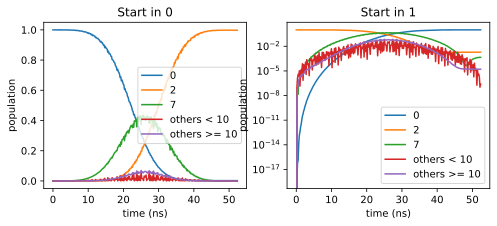

In [50]:
plot_evolution(hspace_full, tlist, props, s=0);
plt.gca().set_yscale("log")

Look at dynamics in a roatating frame:

$$
U = |0\rangle\langle 0|e^{-i(E_9-\omega_A)t} + |2\rangle\langle 2|e^{-i(E_9-\omega_B)t} + |9\rangle\langle 9|e^{-iE_9t}
$$
and for other $n$:
$$
|n\rangle\langle n|e^{-iE_9t}
$$



In [51]:
def U(t, E_int, pulse_args, hspace, logical_idx = [0,1], intermediate=9):
    u = np.zeros((len(hspace), len(hspace)), dtype=np.complex128)
    for i in range(len(hspace)):
        if i == logical_idx[0]:
            u[i,i] = np.exp(-1.0j*(E_int - pulse_args["drive_freq_A"])*t)
        elif i == logical_idx[1]:
            u[i,i] = np.exp(-1.0j*(E_int - pulse_args["drive_freq_B"])*t)
        else:
            u[i,i] = np.exp(1.0j*E_int*t)
    
    return u

plot_evolution(argz, U = lambda t: U(t, w_trans_1, pulse_args, hspace_reduced));

TypeError: plot_evolution() got an unexpected keyword argument 'U'